In [1]:
import pandas as pd

# 1. Đọc dữ liệu gốc
file_path = r'D:\Study\AiTa_Lab_Research\Data_test\BRCA2.csv' # Nhớ thay đổi đường dẫn khớp với máy của bạn
df = pd.read_csv(file_path)

print(f"Tổng số biến thể ban đầu: {len(df)}")

# 2. Xóa các dòng không có điểm số thực nghiệm (NaN)
df = df.dropna(subset=['score'])

# 3. Đảm bảo chỉ lấy Đột biến sai nghĩa (Missense)
df_missense = df[~df['hgvs_pro'].str.contains('Ter|del|ins|=', na=False)].copy()

# 4. Tạo hàm gán nhãn với ngưỡng chính xác từ biểu đồ
def assign_label(score):
    if score <= 1.5:
        return 'patho'
    elif score >= 2.5:
        return 'benign'
    else:
        return 'unknown' # Vùng xám trung gian sẽ bị loại bỏ

df_missense['label'] = df_missense['score'].apply(assign_label)

# 5. Lọc bỏ các biến thể 'unknown'
df_clean = df_missense[df_missense['label'] != 'unknown'].copy()

# 6. Giữ lại các cột cần thiết với hgvs_nt
final_df = df_clean[['hgvs_nt', 'label', 'score']]

# Xuất ra file tạm thời
final_df.to_csv('BRCA2_labeled_for_API.csv', index=False)

print(f"Số biến thể sau khi lọc nhãn (Patho/Benign): {len(final_df)}")
print("Phân bố nhãn:")
print(final_df['label'].value_counts())
print("\n5 dòng đầu tiên chuẩn bị cho API:")
print(final_df.head())

Tổng số biến thể ban đầu: 462
Số biến thể sau khi lọc nhãn (Patho/Benign): 450
Phân bố nhãn:
label
benign    313
patho     137
Name: count, dtype: int64

5 dòng đầu tiên chuẩn bị cho API:
     hgvs_nt   label     score
0  c.7448G>A  benign  5.093829
1  c.7451T>A  benign  3.776840
2  c.7462A>G  benign  2.919432
3  c.7464A>C  benign  2.964786
4  c.7465G>T  benign  4.581064


In [2]:
import pandas as pd
import requests
import json
import time

# 1. Đọc dữ liệu từ Cell 1
df = pd.read_csv('BRCA2_labeled_for_API.csv')

# 2. Ghép mã Transcript chuẩn của BRCA2
df['hgvs_query'] = 'ENST00000380152:' + df['hgvs_nt']
queries = df['hgvs_query'].dropna().unique().tolist()

# 3. Chuẩn bị thông số VEP API
server = "https://rest.ensembl.org"
ext = "/vep/human/hgvs"
headers = {
    "Content-Type": "application/json", 
    "Accept": "application/json"
}

# 4. Gửi request theo lô
chunk_size = 200
vep_results = []

print(f"Bắt đầu truy vấn VEP API cho {len(queries)} đột biến BRCA2...")

for i in range(0, len(queries), chunk_size):
    chunk = queries[i : i + chunk_size]
    data = {"hgvs_notations": chunk}
    
    response = requests.post(server + ext, headers=headers, data=json.dumps(data))
    
    if not response.ok:
        print(f"Lỗi ở lô {i}: {response.status_code}")
        continue
        
    vep_results.extend(response.json())
    print(f"Đã xử lý {min(i + chunk_size, len(queries))}/{len(queries)}")
    time.sleep(0.2)

# 5. Trích xuất 4 cột tọa độ từ JSON
parsed_data = []
for res in vep_results:
    query_input = res.get('input')
    
    chrom = 'chr' + str(res.get('seq_region_name'))
    pos = res.get('start')
    
    allele_string = res.get('allele_string', '')
    if '/' in allele_string:
        ref, alt = allele_string.split('/', 1)
        # Lọc nghiêm ngặt SNV để loại bỏ nhiễu
        if len(ref) == 1 and len(alt) == 1:
            parsed_data.append({
                'hgvs_query': query_input,
                'chrom': chrom,
                'pos': pos,
                'ref': ref,
                'alt': alt
            })

df_parsed = pd.DataFrame(parsed_data)

# 6. Gộp (Merge) lại với file gốc
final_df = pd.merge(df_parsed, df[['hgvs_query', 'label', 'score']], on='hgvs_query', how='inner')

# 7. Cấu trúc lại đúng 5 cột + score
final_df = final_df[['chrom', 'pos', 'ref', 'alt', 'label', 'score']].drop_duplicates()

# 8. Lưu bộ Dataset cuối cùng
final_df.to_csv('BRCA2_Final_Dataset.csv', index=False)
print("\nĐã hoàn thành! Lưu dữ liệu tại: BRCA2_Final_Dataset.csv")
print(final_df.head())

Bắt đầu truy vấn VEP API cho 450 đột biến BRCA2...
Đã xử lý 200/450
Đã xử lý 400/450
Đã xử lý 450/450

Đã hoàn thành! Lưu dữ liệu tại: BRCA2_Final_Dataset.csv
   chrom       pos ref alt   label     score
0  chr13  32356440   G   A  benign  5.093829
1  chr13  32356443   T   A  benign  3.776840
2  chr13  32356454   A   G  benign  2.919432
3  chr13  32356456   A   C  benign  2.964786
4  chr13  32356457   G   T  benign  4.581064


Đang nạp dữ liệu BRCA2...

1. DATASET OVERVIEW (TỔNG QUAN)
Shape (Số dòng, Số cột): (450, 6)

Danh sách các cột (Columns):
['chrom', 'pos', 'ref', 'alt', 'label', 'score']

Kiểu dữ liệu (Data types):
chrom     object
pos        int64
ref       object
alt       object
label     object
score    float64
dtype: object

Số lượng giá trị duy nhất (Unique values):
chrom      1
pos      371
ref        4
alt        4
label      2
score    450
dtype: int64

2. DATA QUALITY (CHẤT LƯỢNG DỮ LIỆU)
Số lượng Missing values ở mỗi cột:
chrom    0
pos      0
ref      0
alt      0
label    0
score    0
dtype: int64

Số lượng dòng trùng lặp (Duplicates): 0

3. UNIVARIATE ANALYSIS (PHÂN TÍCH ĐƠN BIẾN)


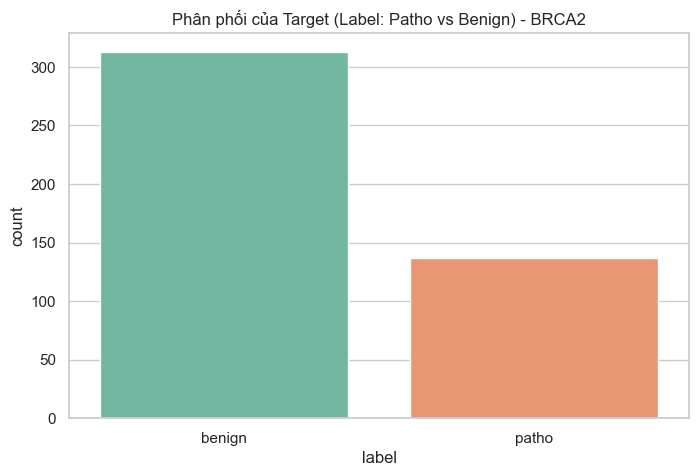

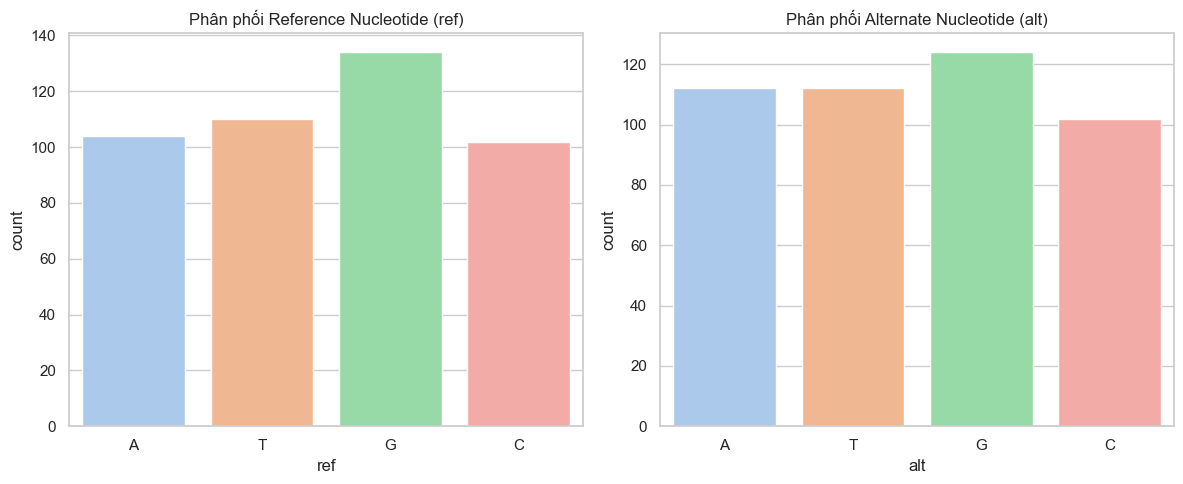

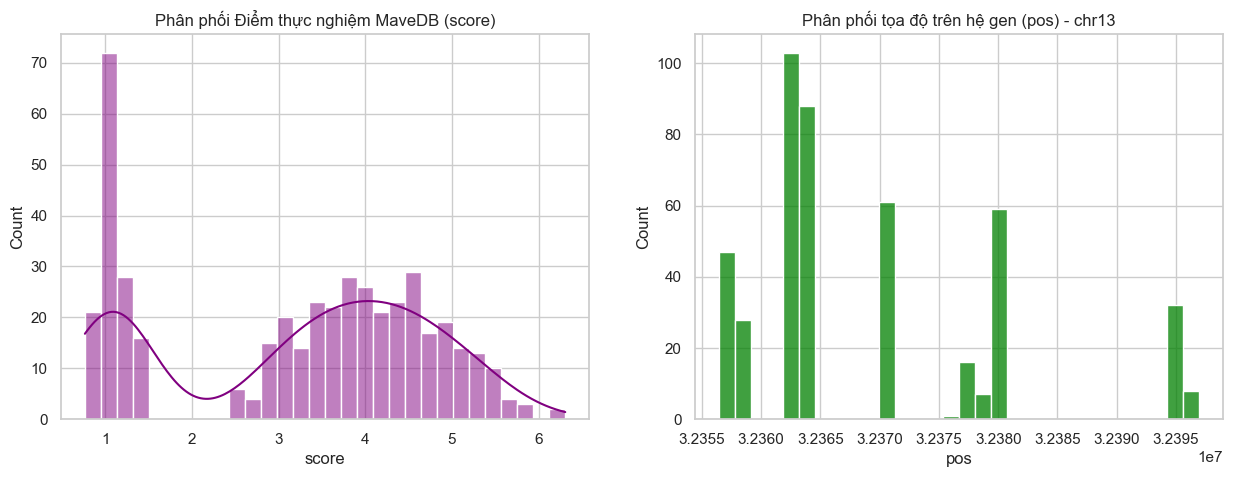


4. OUTLIER ANALYSIS (PHÂN TÍCH NGOẠI LAI TRÊN ĐIỂM SỐ)


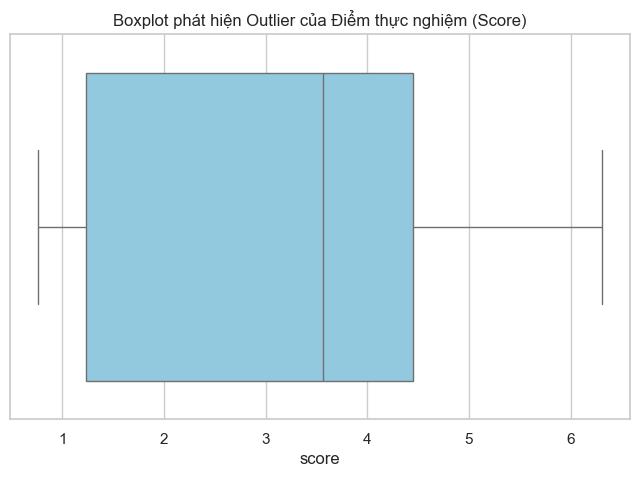

Số lượng Outliers theo IQR (score): 0
Số lượng Outliers theo Z-score > 3 (score): 0

5. BIVARIATE ANALYSIS (PHÂN TÍCH SONG BIẾN)


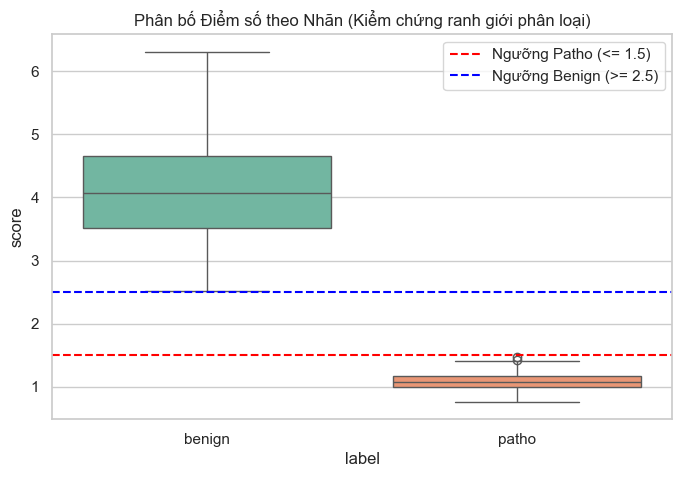

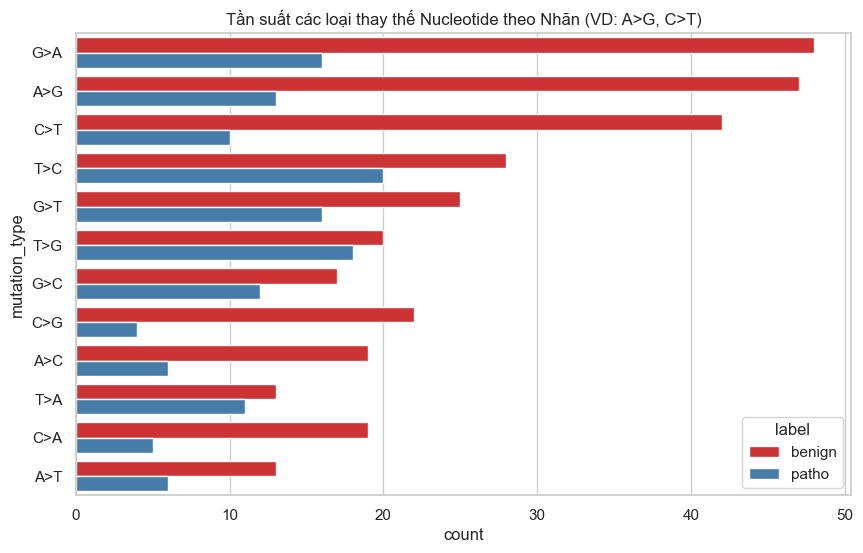


6. CORRELATION ANALYSIS (PHÂN TÍCH TƯƠNG QUAN)


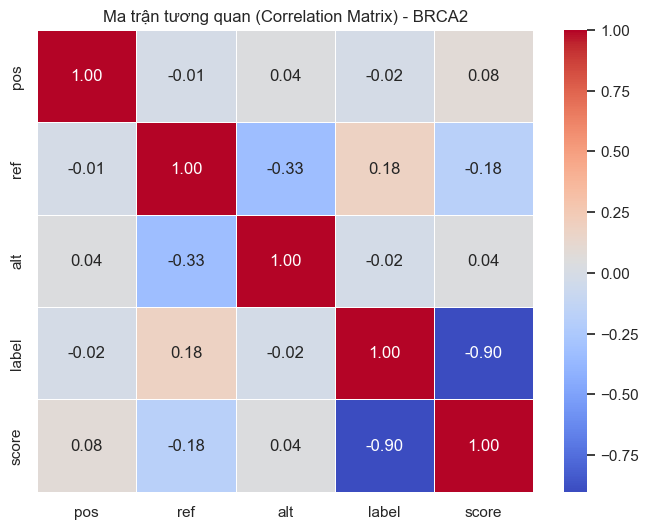


7. THỐNG KÊ TỶ LỆ PATHOGENIC THEO VỊ TRÍ (HOTSPOT ANALYSIS)
- Tỷ lệ đột biến Gây bệnh (Pathogenic) tổng thể của BRCA2: 30.44%
- Thống kê số lượng đột biến theo từng vị trí (Phát hiện Hotspot):
pos
32363370    3
32362675    3
32362524    3
32363367    3
32362666    3
32362587    3
32362672    3
32362633    3
32363369    3
32362647    3
Name: count, dtype: int64

8. DATA INSIGHTS (GỢI Ý RÚT RA KẾT LUẬN CHO AITA LAB)

[GÓC NHÌN ĐÁNH GIÁ MODEL CỦA NHÓM]:
- Kiểm chứng Ranh giới (Boxplot ở phần 5): Đồ thị này chứng minh việc chúng ta loại bỏ vùng xám (từ 1.5 đến 2.5) đã tạo ra một dải phân cách hoàn hảo giữa hai nhãn. Việc này bảo vệ mô hình khỏi dữ liệu nhiễu.
- Phân tích Mutation Type (Phần 5): Biểu đồ A>G, C>T giúp phát hiện liệu sự thay thế Transversion (purine -> pyrimidine) có xu hướng gây bệnh cao hơn Transition hay không, tạo thêm cơ sở để giải thích biểu diễn ẩn LLR của các Foundation Models (EVO2, HyenaDNA).
- Hotspot (Phần 7): Trực quan hóa xem các biến thể có cụm lại ở những vùn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Thiết lập style cho đồ thị
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Đang nạp dữ liệu BRCA2...")
# Nhớ điều chỉnh lại đường dẫn cho khớp với máy của bạn
df = pd.read_csv(r"BRCA2_Final_Dataset.csv")

# Đảm bảo cột pos và score là dạng số
df['pos'] = pd.to_numeric(df['pos'], errors='coerce')
df['score'] = pd.to_numeric(df['score'], errors='coerce')

print("\n" + "="*50)
print("1. DATASET OVERVIEW (TỔNG QUAN)")
print("="*50)
print(f"Shape (Số dòng, Số cột): {df.shape}")
print("\nDanh sách các cột (Columns):")
print(df.columns.tolist())
print("\nKiểu dữ liệu (Data types):")
print(df.dtypes)
print("\nSố lượng giá trị duy nhất (Unique values):")
print(df.nunique())

print("\n" + "="*50)
print("2. DATA QUALITY (CHẤT LƯỢNG DỮ LIỆU)")
print("="*50)
print("Số lượng Missing values ở mỗi cột:")
print(df.isnull().sum())
print(f"\nSố lượng dòng trùng lặp (Duplicates): {df.duplicated().sum()}")

print("\n" + "="*50)
print("3. UNIVARIATE ANALYSIS (PHÂN TÍCH ĐƠN BIẾN)")
print("="*50)
# 3.1 Target Distribution (Phân phối nhãn)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='label', palette='Set2')
plt.title('Phân phối của Target (Label: Patho vs Benign) - BRCA2')
plt.show()

# 3.2 Categorical Distribution (Phân phối Nucleotide)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(data=df, x='ref', ax=axes[0], palette='pastel', order=['A', 'T', 'G', 'C'])
axes[0].set_title('Phân phối Reference Nucleotide (ref)')

sns.countplot(data=df, x='alt', ax=axes[1], palette='pastel', order=['A', 'T', 'G', 'C'])
axes[1].set_title('Phân phối Alternate Nucleotide (alt)')
plt.tight_layout()
plt.show()

# 3.3 Numerical distribution (Phân phối điểm số thực nghiệm và Tọa độ)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df['score'], bins=30, kde=True, ax=axes[0], color='purple')
axes[0].set_title('Phân phối Điểm thực nghiệm MaveDB (score)')

sns.histplot(df['pos'], bins=30, kde=False, ax=axes[1], color='green')
axes[1].set_title('Phân phối tọa độ trên hệ gen (pos) - chr13')
plt.show()

print("\n" + "="*50)
print("4. OUTLIER ANALYSIS (PHÂN TÍCH NGOẠI LAI TRÊN ĐIỂM SỐ)")
print("="*50)
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['score'], color='skyblue')
plt.title('Boxplot phát hiện Outlier của Điểm thực nghiệm (Score)')
plt.show()

# Tính IQR & Z-score cho score
Q1 = df['score'].quantile(0.25)
Q3 = df['score'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = df[(df['score'] < lower_bound) | (df['score'] > upper_bound)]
print(f"Số lượng Outliers theo IQR (score): {len(outliers_iqr)}")

z_scores = np.abs(stats.zscore(df['score'].dropna()))
outliers_z = len(np.where(z_scores > 3)[0])
print(f"Số lượng Outliers theo Z-score > 3 (score): {outliers_z}")

print("\n" + "="*50)
print("5. BIVARIATE ANALYSIS (PHÂN TÍCH SONG BIẾN)")
print("="*50)
# Numerical ↔ Categorical (score vs label) -> Kiểm chứng lại ranh giới
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='label', y='score', palette='Set2')
plt.axhline(1.5, color='red', linestyle='--', label='Ngưỡng Patho (<= 1.5)')
plt.axhline(2.5, color='blue', linestyle='--', label='Ngưỡng Benign (>= 2.5)')
plt.title('Phân bố Điểm số theo Nhãn (Kiểm chứng ranh giới phân loại)')
plt.legend()
plt.show()

# Categorical ↔ Categorical (Sự thay đổi Ref -> Alt)
plt.figure(figsize=(10, 6))
mutation_types = df['ref'] + ">" + df['alt']
df['mutation_type'] = mutation_types
sns.countplot(data=df, y='mutation_type', hue='label', palette='Set1', order=df['mutation_type'].value_counts().index)
plt.title('Tần suất các loại thay thế Nucleotide theo Nhãn (VD: A>G, C>T)')
plt.show()

print("\n" + "="*50)
print("6. CORRELATION ANALYSIS (PHÂN TÍCH TƯƠNG QUAN)")
print("="*50)
# Label Encoding các biến categorical
df_encoded = df[['pos', 'ref', 'alt', 'label', 'score']].copy()
for col in ['ref', 'alt', 'label']:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

corr_matrix = df_encoded.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Ma trận tương quan (Correlation Matrix) - BRCA2')
plt.show()

print("\n" + "="*50)
print("7. THỐNG KÊ TỶ LỆ PATHOGENIC THEO VỊ TRÍ (HOTSPOT ANALYSIS)")
print("="*50)
patho_ratio = (df['label'] == 'patho').mean() * 100
print(f"- Tỷ lệ đột biến Gây bệnh (Pathogenic) tổng thể của BRCA2: {patho_ratio:.2f}%")
print("- Thống kê số lượng đột biến theo từng vị trí (Phát hiện Hotspot):")
hotspots = df['pos'].value_counts().head(10)
print(hotspots)

print("\n" + "="*50)
print("8. DATA INSIGHTS (GỢI Ý RÚT RA KẾT LUẬN CHO AITA LAB)")
print("="*50)
print("""
[GÓC NHÌN ĐÁNH GIÁ MODEL CỦA NHÓM]:
- Kiểm chứng Ranh giới (Boxplot ở phần 5): Đồ thị này chứng minh việc chúng ta loại bỏ vùng xám (từ 1.5 đến 2.5) đã tạo ra một dải phân cách hoàn hảo giữa hai nhãn. Việc này bảo vệ mô hình khỏi dữ liệu nhiễu.
- Phân tích Mutation Type (Phần 5): Biểu đồ A>G, C>T giúp phát hiện liệu sự thay thế Transversion (purine -> pyrimidine) có xu hướng gây bệnh cao hơn Transition hay không, tạo thêm cơ sở để giải thích biểu diễn ẩn LLR của các Foundation Models (EVO2, HyenaDNA).
- Hotspot (Phần 7): Trực quan hóa xem các biến thể có cụm lại ở những vùng tọa độ nhất định (domain chức năng) của gen BRCA2 hay không. Nếu có, các lớp Attention trong Lớp Hòa trộn (Fusion Layer) sẽ học được rất mạnh tín hiệu bảo tồn tại các vị trí này.
""")